In [134]:
import pandas as pd
import matplotlib.pyplot as plt

In [135]:
# Load the data from the CSV file
df = pd.read_csv("../data/raw/data-v5.csv")

# Display the first few rows to verify the data was loaded correctly
df.head(1)

,propertyId,localityName,postalCode,typeOfProperty,subtypeOfProperty,price,typeOfSale,numberOfRooms,livingArea,equippedKitchen,...,hasThermicPanels,hasCollectiveWaterHeater,hasDoubleGlazing,epcScore,primaryEnergyConsumptionPerSqm,renovationObligation,cadastralIncome,parkingCountIndoor,parkingCountOutdoor,parkingCountClosedBox
0,20665504,Virton Ruette,6760,0,0,249000,0,8,164,2,...,-1,-1,-1,6,486,-1,570,1,1,-1


Seek for missing values

In [136]:
# Replace all -1 values with NaN across the dataframe
df = df.replace(-1, pd.NA)

# Display updated missing values count to verify the changes
updated_missings = df.isna().sum()
print("Updated missing values count:")
print(updated_missings)

Updated missing values count:
propertyId                               0
localityName                             0
postalCode                               0
typeOfProperty                           0
subtypeOfProperty                        0
price                                    1
typeOfSale                               0
numberOfRooms                            0
livingArea                             370
equippedKitchen                      30973
furnished                            43191
openFire                                 0
garden                               53033
surfaceOfGood                        35103
numberOfFacades                      22320
swimmingPool                         42811
stateOfBuilding                      18357
latitude                             10587
longitude                            10587
terraceSurface                       41899
hasBasement                          41899
hasDressingRoom                      52351
hasDisabledAccess       

Drop useless columns

In [137]:
cols_before = df.shape[1]

# Delete the parkingCountClosedBox & gardenOrientation & hasDressingRoom & hasLaundryRoom & hasCollectiveWaterHeater column because too much missing values
# Delete the streetFacadeWidth column because it is biased since aparts & houses are mixed in the dataset
# Delete the latitude & longitude & localityName columns because they are not useful for the model
df = df.drop(columns=['parkingCountClosedBox', 'gardenOrientation', 'hasDressingRoom', 'hasLaundryRoom', 'hasCollectiveWaterHeater', 'streetFacadeWidth', 'latitude', 'longitude', 'localityName'], errors='ignore')

print(f"Columns deleted: {cols_before - df.shape[1]}")

Columns deleted: 9


Remove the only row where there is no price and few rows with price lower than 25k€

In [138]:
rows_before = df.shape[0]

df.dropna(subset=['price'], inplace=True)

df = df[df['price'].astype(float) >= 25000]

print(f"Rows dropped : {rows_before - df.shape[0]}")

Rows dropped : 30


Assuming some field have missing values that should be false (0)

In [139]:
df['furnished'].replace(pd.NA, 0, inplace=True) #if furnished is NaN it probably means it's not furnished, replace with 0
df['swimmingPool'].replace(pd.NA, 0, inplace=True) #if swimmingPool is NaN it probably means it's not there, replace with 0
df['parkingCountIndoor'].replace(pd.NA, 0, inplace=True) #if parkingCountIndoor is NaN it probably means it's not there, replace with 0
df['parkingCountOutdoor'].replace(pd.NA, 0, inplace=True) #if parkingCountOutdoor is NaN it probably means it's not there, replace with 0
df['livingRoomSurface'].replace(pd.NA, 0, inplace=True) #if livingRoomSurface is NaN it probably means there is no livingRoom so replace with 0
df['terraceSurface'].replace(pd.NA, 0, inplace=True) #if terraceSurface is NaN it probably means there is no terrace so replace with 0

C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\1532317641.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['furnished'].replace(pd.NA, 0, inplace=True) #if furnished is NaN it probably means it's not furnished, replace with 0
C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\1532317641.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_

Assuming other fields have unknown values (-1) it could be true or false

In [140]:
df['equippedKitchen'].replace(pd.NA, -1, inplace=True)

C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\240968195.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['equippedKitchen'].replace(pd.NA, -1, inplace=True)
C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\240968195.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['equippedKitchen']

Replace living area missing values with the median

In [141]:
# Calculate the median of non-NaN values
living_area_median = df['livingArea'].median()

# Replace NaN values with the median
df['livingArea'].replace(pd.NA, living_area_median, inplace=True)

# Verify the changes
print(f"\nMedian living area used for replacement: {living_area_median}")
print(f"Number of NaN values in livingArea after replacement: {df['livingArea'].isna().sum()}")
print(f"Updated livingArea dtype: {df['livingArea'].dtype}")



Median living area used for replacement: 130.0
Number of NaN values in livingArea after replacement: 0
Updated livingArea dtype: float64


C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\980291436.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['livingArea'].replace(pd.NA, living_area_median, inplace=True)
C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\980291436.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['living

Making a Plot to see house vs apartment proportion (Thx Copilot)

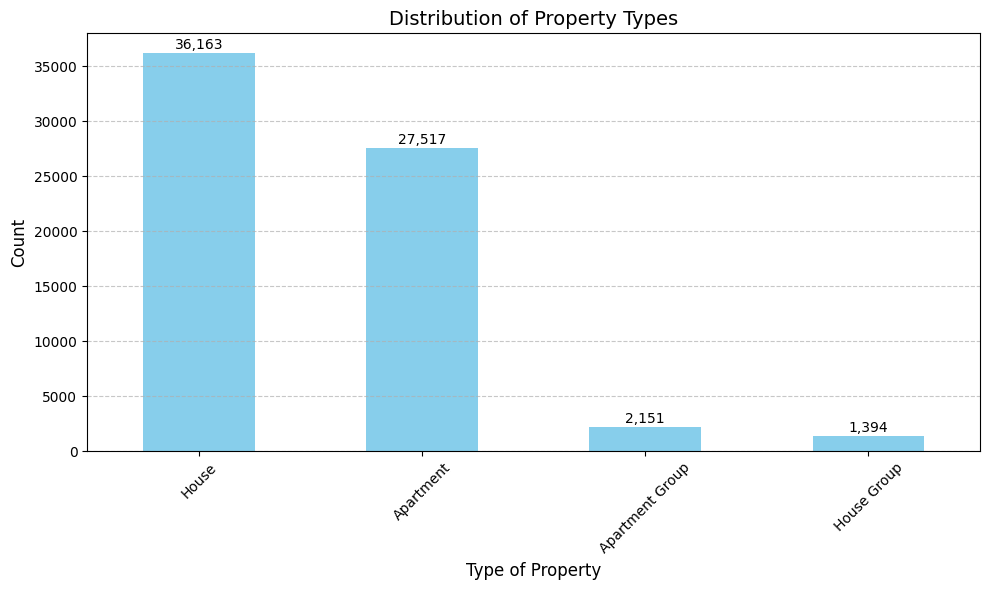

In [142]:

# Create a mapping of numeric codes to readable property types
property_type_mapping = {
    0: 'House', 
    1: 'Apartment', 
    2: 'House Group', 
    3: 'Apartment Group'
}

# Replace numeric codes with their text descriptions
type_counts = df['typeOfProperty'].value_counts()
type_counts.index = [property_type_mapping.get(x, f'Type {x}') for x in type_counts.index]

# Create a more visually appealing bar plot
plt.figure(figsize=(10, 6))
ax = type_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Property Types', fontsize=14)
plt.xlabel('Type of Property', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add count labels on top of each bar
for i, v in enumerate(type_counts):
    ax.text(i, v + 0.01*max(type_counts), f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()

Make Separate Data frame for house+housegroups & aparts+apartgroups

In [143]:
df_houses = df.query('typeOfProperty == 0 or typeOfProperty == 2')
df_aparts = df.query('typeOfProperty == 1 or typeOfProperty == 3')

In [144]:
print(f"Total records : {df_houses.shape[0]}")
df_houses.isna().sum()

Total records : 37557


propertyId                               0
postalCode                               0
typeOfProperty                           0
subtypeOfProperty                        0
price                                    0
typeOfSale                               0
numberOfRooms                            0
livingArea                               0
equippedKitchen                          0
furnished                                0
openFire                                 0
garden                               25321
surfaceOfGood                         5425
numberOfFacades                       8265
swimmingPool                             0
stateOfBuilding                       9678
terraceSurface                           0
hasBasement                          22513
hasDisabledAccess                    21322
hasLift                              20885
livingRoomSurface                        0
electricalInstallationCertificate    17290
gScore                               22542
heatingType

Clean the data for houses

In [145]:
df_houses['hasLift'].replace(pd.NA, 0, inplace=True) # Assuming there is mostly no lifts in houses

#misses floorCount value to evaluate if there is DisabledAccess or not :/
df_houses['hasDisabledAccess'].replace(pd.NA, 0, inplace=True) # Assuming there is mostly no disabled access in houses especially with multiple floors

C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\269380485.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_houses['hasLift'].replace(pd.NA, 0, inplace=True) # Assuming there is mostly no lifts in houses
C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\269380485.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_

In [146]:
print(f"Total records : {df_aparts.shape[0]}")
df_aparts.isna().sum()

Total records : 29668


propertyId                               0
postalCode                               0
typeOfProperty                           0
subtypeOfProperty                        0
price                                    0
typeOfSale                               0
numberOfRooms                            0
livingArea                               0
equippedKitchen                          0
furnished                                0
openFire                                 0
garden                               27691
surfaceOfGood                        29668
numberOfFacades                      14042
swimmingPool                             0
stateOfBuilding                       8669
terraceSurface                           0
hasBasement                          19366
hasDisabledAccess                    15814
hasLift                               8148
livingRoomSurface                        0
electricalInstallationCertificate    13112
gScore                               18140
heatingType

Clean the data for aparts

In [147]:
df_aparts['garden'].replace(pd.NA, 0, inplace=True) # Assuming there is mostly no garden in apartments

df_aparts['hasLift'].replace(pd.NA, -1, inplace=True) # Assuming there could be lifts so (-1) unknown

C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\3457789142.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_aparts['garden'].replace(pd.NA, 0, inplace=True) # Assuming there is mostly no garden in apartments
C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\3457789142.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_s

In [148]:
# set surfaceOfGood to livingArea for apartments
df_aparts['surfaceOfGood'] = df_aparts['livingArea']

C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\3551886252.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aparts['surfaceOfGood'] = df_aparts['livingArea']


Now Merge houses and aparts again

In [149]:
# Merge the cleaned house and apartment dataframes
df_cleaned = pd.concat([df_houses, df_aparts], axis=0)

# Sort by property ID to maintain some order
df_cleaned = df_cleaned.sort_values('propertyId')

# Reset the index for cleaner access
df_cleaned = df_cleaned.reset_index(drop=True)

df_cleaned.replace(pd.NA, -1, inplace=True)

# Display basic info about the merged dataframe
print(f"Total records: {df_cleaned.shape[0]}")
print(f"Total columns: {df_cleaned.shape[1]}")
print(f"Houses: {len(df_houses)}, Apartments: {len(df_aparts)}, Total: {len(df_houses) + len(df_aparts)}")


Total records: 67225
Total columns: 34
Houses: 37557, Apartments: 29668, Total: 67225


C:\Users\ImJus\AppData\Local\Temp\ipykernel_12116\2764776545.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned.replace(pd.NA, -1, inplace=True)


Remove Outliers : Using IQR (Interquartile Range)

In [150]:
# Q1 = df_cleaned.quantile(0.25)
# Q3 = df_cleaned.quantile(0.75)
# IQR = Q3 - Q1

# df_clean = df_cleaned[~((df_cleaned < (Q1 - 1.5 * IQR)) | (df_cleaned > (Q3 + 1.5 * IQR))).any(axis=1)]

Or Using Z-score (standardized distance) - (Working great with XGBoost)

In [151]:
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(zscore(df_cleaned.select_dtypes(include=np.number)))
df_clean = df_cleaned[(z_scores < 3).all(axis=1)]  # Keep rows with z-score <

Save cleaned data

In [152]:
# Save the cleaned dataframe to a CSV file
df_clean.to_csv("../data/clean/data.csv", index=False)
print("Cleaned data saved successfully to ../data/clean/data.csv")

Cleaned data saved successfully to ../data/clean/data.csv
